<a href="https://colab.research.google.com/github/futabarentarou/Rentarou-interacting-with-api-python-project-tutorial/blob/main/linear_regresion_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/4GeeksAcademy/regularized-linear-regression-project-tutorial/main/demographic_health_data.csv"
df = pd.read_csv(url)

df.head()

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,1009,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2


In [3]:
df.shape

df.info()

df.describe().T

df.isnull().sum().sort_values(ascending=False).head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3140 entries, 0 to 3139
Columns: 108 entries, fips to Urban_rural_code
dtypes: float64(61), int64(45), object(2)
memory usage: 2.6+ MB


,0
fips,0
TOT_POP,0
0-9,0
0-9 y/o % of total pop,0
19-Oct,0
10-19 y/o % of total pop,0
20-29,0
20-29 y/o % of total pop,0
30-39,0
30-39 y/o % of total pop,0


In [4]:
df = df.drop_duplicates().reset_index(drop=True)

df = df.drop(columns=["fips"], errors="ignore")

In [5]:
target = "Heart disease_number"

In [6]:
df = df.select_dtypes(include=["int64", "float64"])

In [7]:
X = df.drop(columns=[target])
y = df[target]

In [8]:
from sklearn.model_selection import train_test_split

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
from sklearn.preprocessing import StandardScaler

# Escalar variables predictoras
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

lr_mse = mean_squared_error(y_test, y_pred_lr)
lr_r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression MSE:", lr_mse)
print("Linear Regression R2:", lr_r2)

Linear Regression MSE: 140377.608008782
Linear Regression R2: 0.9983961514653388


In [11]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=1.0, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)

y_pred_lasso = lasso_model.predict(X_test_scaled)

lasso_mse = mean_squared_error(y_test, y_pred_lasso)
lasso_r2 = r2_score(y_test, y_pred_lasso)

print("Lasso MSE:", lasso_mse)
print("Lasso R2:", lasso_r2)

Lasso MSE: 136351.42300389556
Lasso R2: 0.998442151614593


In [12]:
results = pd.DataFrame({
    "Modelo": ["Linear Regression", "Lasso"],
    "MSE": [lr_mse, lasso_mse],
    "R2": [lr_r2, lasso_r2]
})

results

,Modelo,MSE,R2
0,Linear Regression,140377.608009,0.998396
1,Lasso,136351.423004,0.998442


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.410e+08, tolerance: 7.097e+07
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.812e+07, tolerance: 7.097e+07
  model = cd_fast.enet_coordinate_descent(


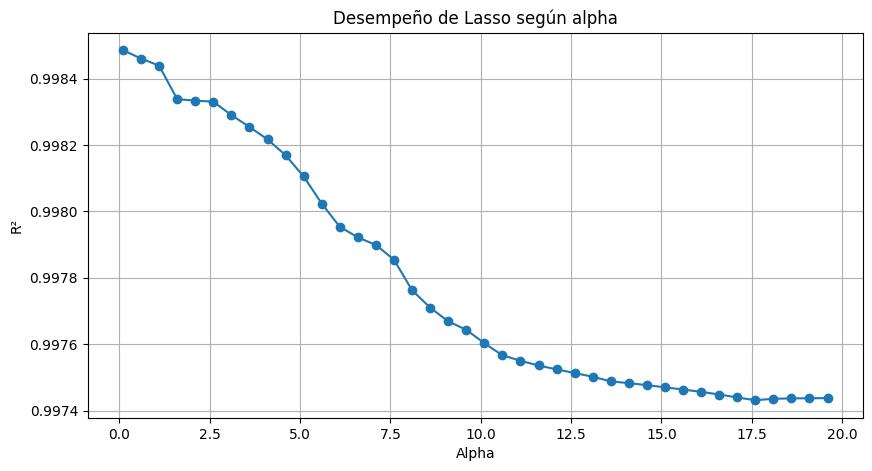

In [13]:
import numpy as np
import matplotlib.pyplot as plt

alphas = np.arange(0.1, 20.1, 0.5)
r2_scores = []

for alpha in alphas:
    model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    r2_scores.append(r2_score(y_test, y_pred))

plt.figure(figsize=(10, 5))
plt.plot(alphas, r2_scores, marker="o")
plt.xlabel("Alpha")
plt.ylabel("R²")
plt.title("Desempeño de Lasso según alpha")
plt.grid(True)
plt.show()

In [14]:
best_alpha = alphas[np.argmax(r2_scores)]
best_r2 = max(r2_scores)

print("Mejor alpha:", best_alpha)
print("Mejor R2:", best_r2)

best_lasso = Lasso(alpha=best_alpha, max_iter=10000)
best_lasso.fit(X_train_scaled, y_train)

y_pred_best = best_lasso.predict(X_test_scaled)

best_mse = mean_squared_error(y_test, y_pred_best)
best_r2 = r2_score(y_test, y_pred_best)

print("MSE optimizado:", best_mse)
print("R2 optimizado:", best_r2)

Mejor alpha: 0.1
Mejor R2: 0.9984851795412111
MSE optimizado: 132585.38320295326
R2 optimizado: 0.9984851795412111


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.410e+08, tolerance: 7.097e+07
  model = cd_fast.enet_coordinate_descent(
